In [115]:
import pandas as pd
import matplotlib.pyplot as plt 

TFP data extracting 

In [116]:
TFP_df=pd.read_csv(r"C:\Users\zalew\OneDrive\Desktop\Projects\Singapore_analisys\data\TFP.csv")

TFP_df["observation_date"]=TFP_df["observation_date"].str.split("-").str[0].astype(int)
TFP_df=TFP_df[TFP_df["observation_date"].between(1990,2023)]
TFP_df=TFP_df.rename(columns={"observation_date":"Year", "value":"TFP"})
print(TFP_df)

    Year  RTFPNASGA632NRUG
26  1990          1.025900
27  1991          1.013372
28  1992          1.006313
29  1993          1.051253
30  1994          1.083044
31  1995          1.074934
32  1996          1.049521
33  1997          1.024420
34  1998          0.933121
35  1999          0.925856
36  2000          0.932715
37  2001          0.890153
38  2002          0.896000
39  2003          0.922271
40  2004          0.982537
41  2005          1.008678
42  2006          1.025440
43  2007          1.030262
44  2008          0.979085
45  2009          0.939894
46  2010          1.001151
47  2011          1.016282
48  2012          1.006733
49  2013          0.999832
50  2014          0.994693
51  2015          0.990815
52  2016          0.996705
53  2017          1.014691
54  2018          1.019997
55  2019          0.998375
56  2020          0.967580
57  2021          1.000000
58  2022          1.009614
59  2023          0.991359


Index 2021=1

FDA exctracting

In [117]:

FDA_df = pd.read_csv(
    "data/FDA.csv",
    skiprows=4,
    header=0
)
singapore = FDA_df[FDA_df["Country Code"] == "SGP"].copy()
years = [str(y) for y in range(1990, 2024)]
fdi = singapore[["Country Name"] + years].copy()

fdi_long = fdi.melt(
    id_vars="Country Name",
    var_name="Year",
    value_name="FDI"
)

fdi_long["Year"] = fdi_long["Year"].astype(int)
fdi_long["FDI"]  = pd.to_numeric(fdi_long["FDI"], errors="coerce")
fdi_long = fdi_long.dropna(subset=["FDI"])
#converting to bilions
fdi_long["FDI_billions"] = fdi_long["FDI"] / 1e9

print(fdi_long[["Year", "FDI_billions"]].to_string(index=False))

 Year  FDI_billions
 1990      5.574739
 1991      4.887094
 1992      2.204342
 1993      4.686312
 1994      8.550165
 1995     11.942852
 1996     11.432364
 1997     15.701784
 1998      5.958646
 1999     18.852989
 2000     15.515295
 2001     17.006819
 2002      6.157194
 2003     17.051420
 2004     24.390255
 2005     19.316059
 2006     39.129332
 2007     47.337948
 2008     13.598299
 2009     23.436064
 2010     55.322434
 2011     49.155657
 2012     55.310808
 2013     64.389515
 2014     68.698473
 2015     69.774553
 2016     65.133174
 2017    101.970056
 2018     86.126491
 2019    106.174186
 2020     79.322385
 2021    142.313340
 2022    144.147824
 2023    125.786784


net inflows

ECI exctracting 

In [118]:
ECI_df = pd.read_csv("data/ECI.csv")

singapore = ECI_df[ECI_df["country_iso3_code"] == "SGP"].copy()


singapore = singapore[
    (singapore["year"] >= 1990) &
    (singapore["year"] <= 2023)
]

eci = singapore[["year", "eci_hs92", "eci_rank_hs92"]].copy()
eci.columns = ["Year", "ECI", "ECI_Rank"]

eci = eci.sort_values("Year").reset_index(drop=True)
eci
print(eci.to_string(index=False))

 Year   ECI  ECI_Rank
 1995 0.922        25
 1996 0.956        27
 1997 0.952        27
 1998 0.930        27
 1999 1.006        23
 2000 1.130        19
 2001 1.146        19
 2002 1.199        18
 2003 1.282        14
 2004 1.298        12
 2005 1.232        13
 2006 1.233        12
 2007 1.321        10
 2008 1.301        13
 2009 1.420         8
 2010 1.471         7
 2011 1.493         9
 2012 1.452         8
 2013 1.483         7
 2014 1.465         7
 2015 1.564         6
 2016 1.603         5
 2017 1.571         5
 2018 1.631         5
 2019 1.681         5
 2020 1.672         5
 2021 1.664         5
 2022 1.651         5
 2023 1.679         5


Economic Complexity Index calculated using HS92 product classification,"A measure of the knowledge in a society as expressed in the products it makes. The economic complexity of a country is calculated based on the diversity of exports a country produces and their ubiquity, or the number of the countries able to produce them (and those countries’ complexity)."

GDP exctracting

In [119]:
GDP_df = pd.read_csv("data/GDP.csv", skiprows=4)
GDP_df_singapore = GDP_df[GDP_df['Country Name'] == 'Singapore'].T.copy()
GDP_df_singapore = GDP_df_singapore.reset_index()
GDP_df_singapore.columns = ['Year', 'GDP_Value_bilions']

GDP_df_singapore['Year'] = pd.to_numeric(GDP_df_singapore['Year'], errors='coerce')
GDP_df_singapore = GDP_df_singapore.dropna(subset=['Year'])

GDP_df_singapore['Year'] = GDP_df_singapore['Year'].astype(int)
GDP_df_singapore = GDP_df_singapore[GDP_df_singapore['Year'] >= 1990]

GDP_df_singapore = GDP_df_singapore.dropna(subset=['GDP_Value_bilions'])
GDP_df_singapore = GDP_df_singapore.reset_index(drop=True)
GDP_df_singapore["GDP_Value_bilions"]=GDP_df_singapore["GDP_Value_bilions"]/1e9

print(GDP_df_singapore)

    Year GDP_Value_bilions
0   1990         36.144337
1   1991         45.466165
2   1992          52.13132
3   1993         60.603816
4   1994         73.688724
5   1995         87.812541
6   1996         96.293087
7   1997        100.123787
8   1998         85.728208
9   1999          86.28685
10  2000          96.07654
11  2001         89.793791
12  2002         92.538373
13  2003         97.646401
14  2004        115.033593
15  2005        127.807849
16  2006        148.627286
17  2007        180.941701
18  2008        193.617324
19  2009        194.150284
20  2010        239.807981
21  2011        279.356499
22  2012        295.092888
23  2013        307.576361
24  2014        314.863581
25  2015        307.998545
26  2016        319.646469
27  2017        343.673335
28  2018        377.123711
29  2019        376.161999
30  2020        349.165859
31  2021        436.591382
32  2022        509.017841
33  2023        505.439514
34  2024        547.386646


"GDP (current US$)","Gross domestic product is the total income earned through the production of goods and services in an economic territory during an accounting period. It can be measured in three different ways: using either the expenditure approach, the income approach, or the production approach. This indicator is expressed in current prices, meaning no adjustment has been made to account for price changes over time. This indicator is expressed in United States dollars.

Creating one data set 

In [120]:
          
df= pd.merge(TFP_df, fdi_long[["Year", "FDI_billions"]], on="Year", how="inner")
df= pd.merge(df, eci[["Year", "ECI"]], on="Year", how="inner")
df= pd.merge(df, GDP_df_singapore[["Year", "GDP_Value_bilions"]], on="Year", how="inner")
df.columns=["Years","TFP","FDI_billions"	,"ECI"	,"GDP_Value_bilions"]
df

,Years,TFP,FDI_billions,ECI,GDP_Value_bilions
0,1995,1.074934,11.942852,0.922,87.812541
1,1996,1.049521,11.432364,0.956,96.293087
2,1997,1.024420,15.701784,0.952,100.123787
3,1998,0.933121,5.958646,0.930,85.728208
4,1999,0.925856,18.852989,1.006,86.28685
5,2000,0.932715,15.515295,1.130,96.07654
6,2001,0.890153,17.006819,1.146,89.793791
7,2002,0.896000,6.157194,1.199,92.538373
8,2003,0.922271,17.051420,1.282,97.646401
9,2004,0.982537,24.390255,1.298,115.033593


Grphs with dates of FTA signed 

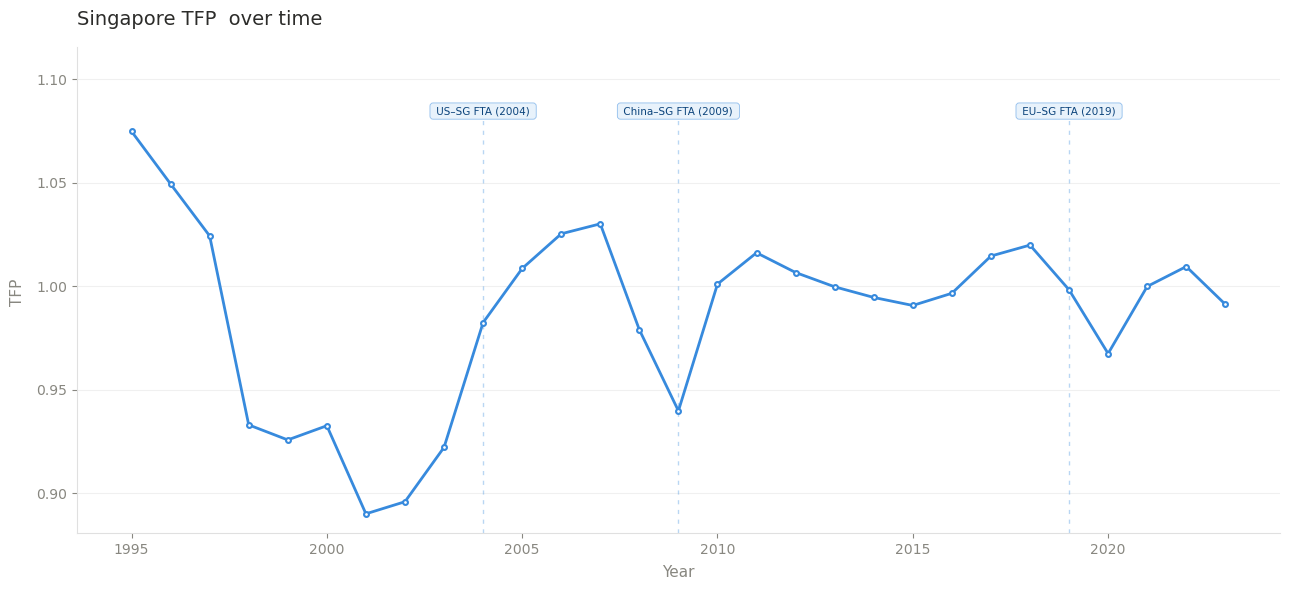

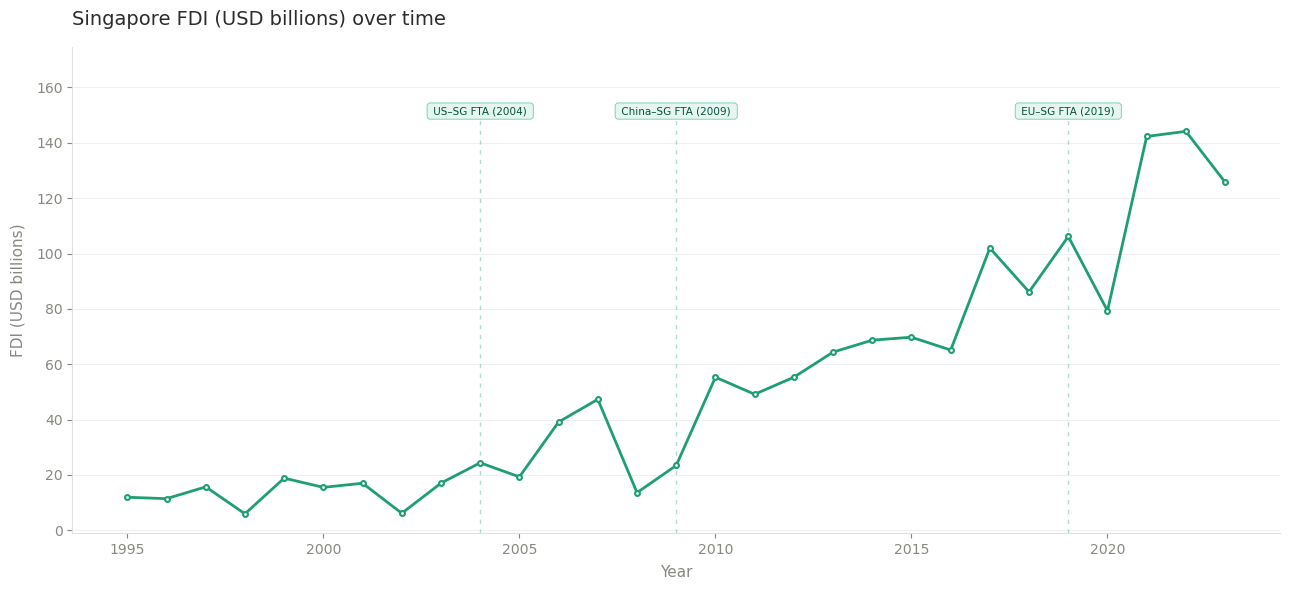

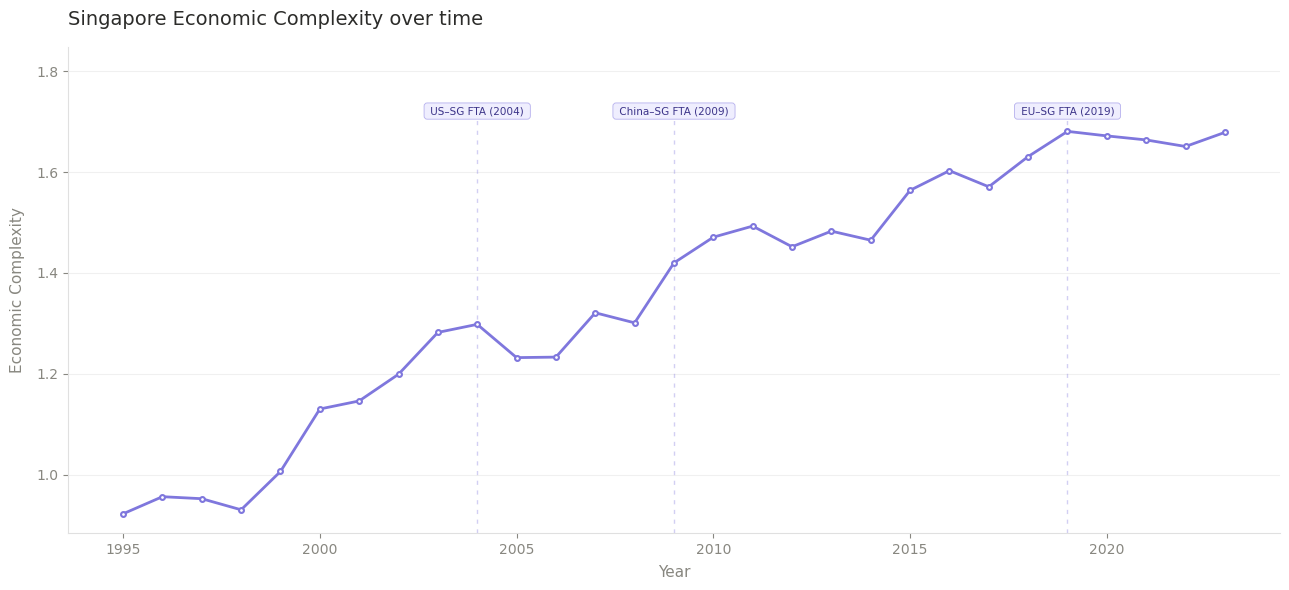

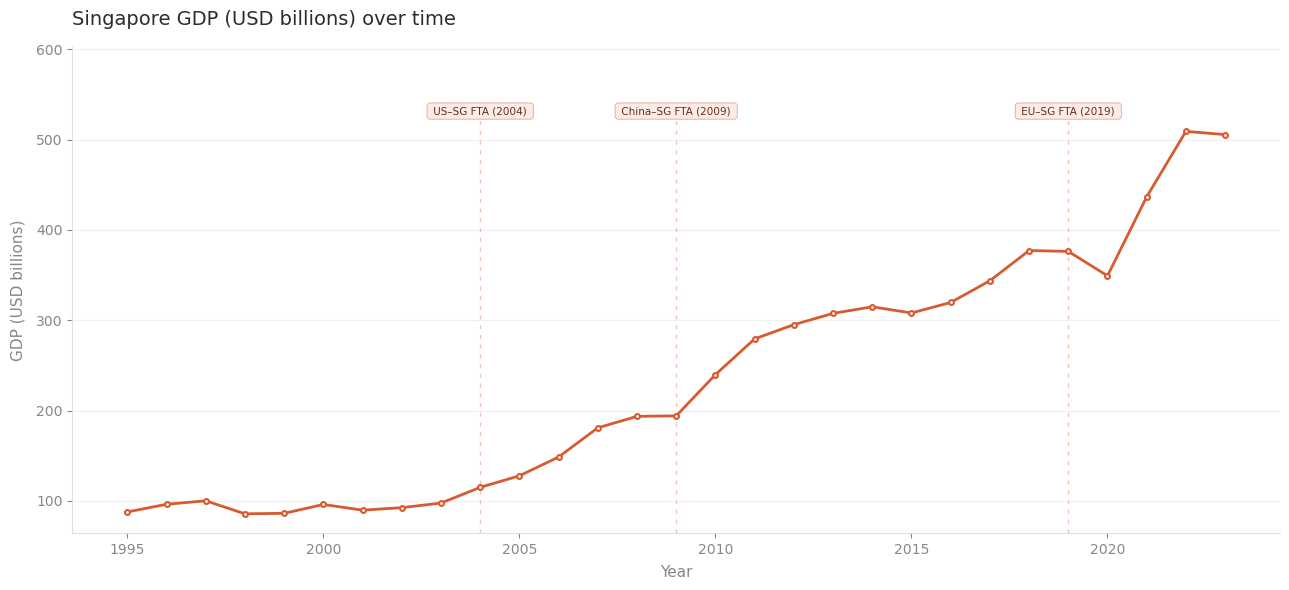

In [121]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    ("TFP",               "TFP ",                  "#378ADD"),
    ("FDI_billions",      "FDI (USD billions)",    "#1D9E75"),
    ("ECI",               "Economic Complexity",   "#7F77DD"),
    ("GDP_Value_bilions", "GDP (USD billions)",    "#D85A30"),
]

fta_years = {
    "ASEAN FTA (1993)":   1993,
    "US–SG FTA (2004)":   2004,
    "China–SG FTA (2009)": 2009,
    "EU–SG FTA (2019)":   2019,
}

pill_colors = {
    "#378ADD": ("#E6F1FB", "#85B7EB", "#0C447C"),
    "#1D9E75": ("#E1F5EE", "#5DCAA5", "#085041"),
    "#7F77DD": ("#EEEDFE", "#AFA9EC", "#3C3489"),
    "#D85A30": ("#FAECE7", "#F0997B", "#712B13"),
}

for col, ylabel, color in metrics:
    fig, ax = plt.subplots(figsize=(13, 6))

    series = df[col].dropna()
    x = df.loc[series.index, 'Years']

    ax.plot(x, series,
            color=color, linewidth=2,
            marker='o', markersize=3.5,
            markerfacecolor='white', markeredgewidth=1.5,
            zorder=3)

    ymin, ymax = series.min(), series.max()
    y_range = ymax - ymin
    pill_face, pill_edge, pill_text = pill_colors[color]

    for label, year in fta_years.items():
        if year < x.min() or year > x.max():
            continue

        ax.axvline(year,
                   ymin=0, ymax=0.88,
                   color=color, alpha=0.35,
                   linewidth=1, linestyle=(0, (3, 4)),
                   zorder=2)

        pill_y = ymax + y_range * 0.04
        ax.text(year, pill_y, f" {label} ",
                fontsize=7.5, color=pill_text,
                ha='center', va='bottom',
                bbox=dict(
                    boxstyle='round,pad=0.3',
                    facecolor=pill_face,
                    edgecolor=pill_edge,
                    linewidth=0.6,
                    alpha=0.9,
                ),
                zorder=4)

    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#e0e0e0')
    ax.spines['bottom'].set_color('#e0e0e0')
    ax.tick_params(colors='#888780', labelsize=10)
    ax.yaxis.label.set_color('#888780')
    ax.xaxis.label.set_color('#888780')
    ax.set_ylabel(ylabel, fontsize=11, labelpad=8)
    ax.set_xlabel("Year", fontsize=11, labelpad=6)
    ax.set_title(f"Singapore {ylabel} over time",
                 fontsize=14, fontweight='normal',
                 color='#2C2C2A', pad=16, loc='left')
    ax.grid(axis='y', color='#f0f0f0', linewidth=0.8, zorder=0)
    ax.grid(axis='x', visible=False)
    ax.set_ylim(ymin - y_range * 0.05, ymax + y_range * 0.22)

    plt.tight_layout()
   
    plt.show()
    plt.close()

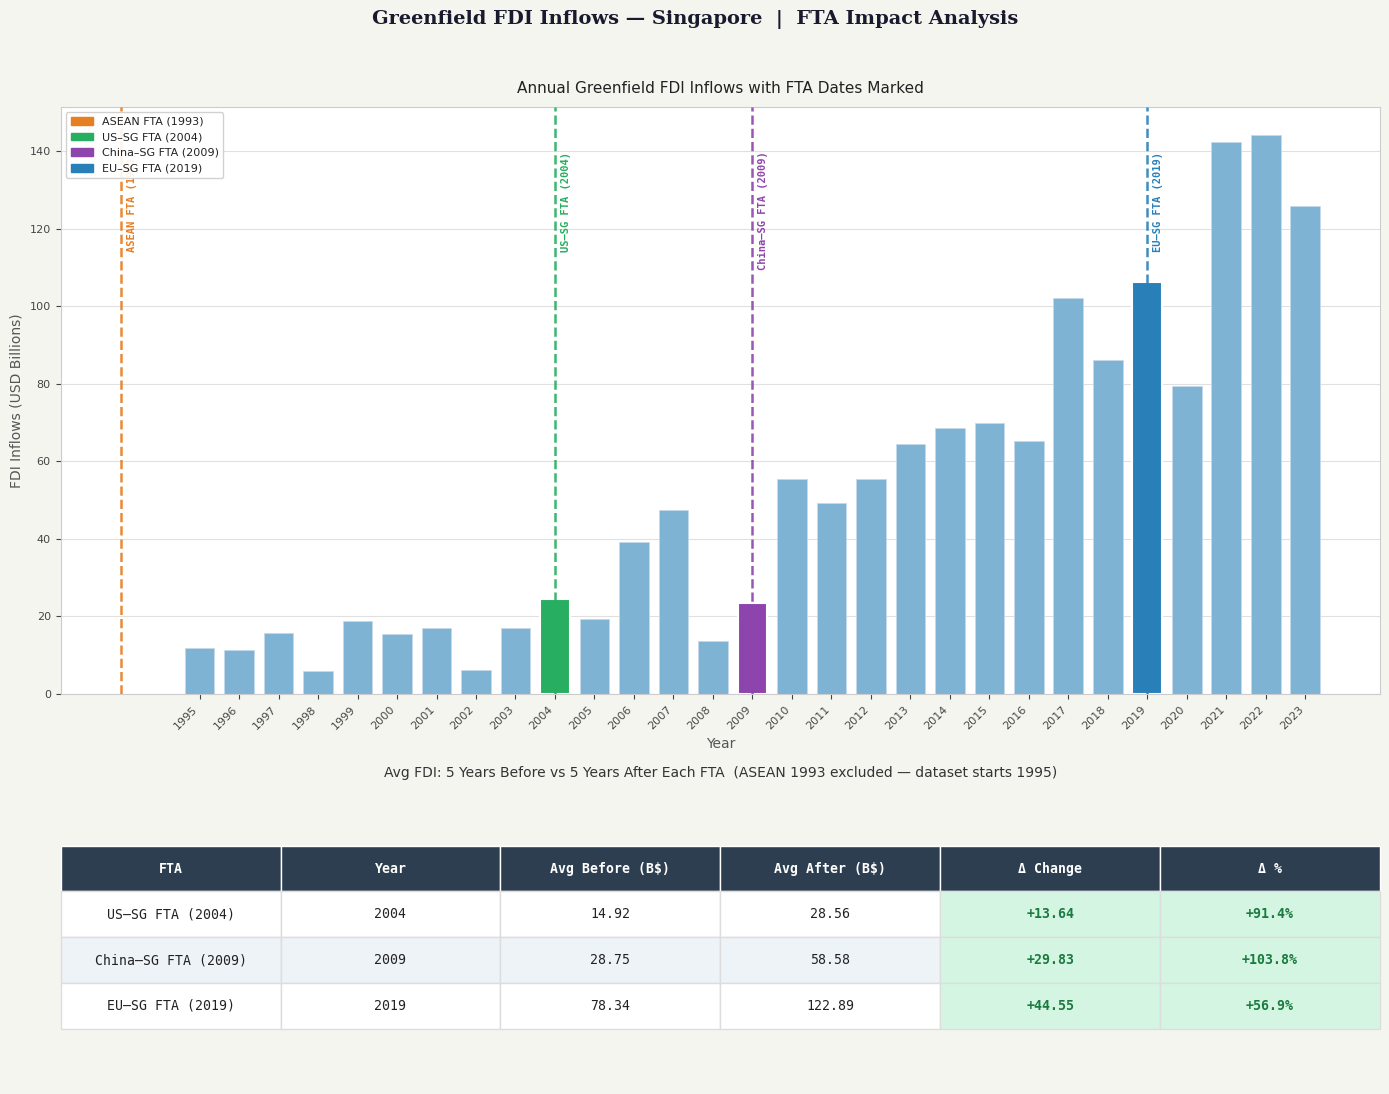

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches



fta_years = {
    "ASEAN FTA (1993)":    1993,
    "US–SG FTA (2004)":    2004,
    "China–SG FTA (2009)": 2009,
    "EU–SG FTA (2019)":    2019,
}

FTA_COLORS = {
    "ASEAN FTA (1993)":    "#e67e22",
    "US–SG FTA (2004)":    "#27ae60",
    "China–SG FTA (2009)": "#8e44ad",
    "EU–SG FTA (2019)":    "#2980b9",
}


TABLE_FTAS = {k: v for k, v in fta_years.items() if k != "ASEAN FTA (1993)"}
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 11),
    gridspec_kw={"height_ratios": [2, 1]},
    facecolor="#f5f5f0",
)
fig.suptitle(
    "Greenfield FDI Inflows — Singapore  |  FTA Impact Analysis",
    fontsize=14, fontweight="bold", color="#1a1a2e",
    y=0.99, fontfamily="serif",
)
ax1 = axes[0]
ax1.set_facecolor("#ffffff")

bars = ax1.bar(
    df["Years"], df["FDI_billions"],
    color="#7fb3d3", edgecolor="#c5daea", linewidth=0.6, zorder=2, width=0.75,
)


fta_year_lookup = {v: k for k, v in fta_years.items()}
for bar, yr in zip(bars, df["Years"]):
    if yr in fta_year_lookup:
        bar.set_color(FTA_COLORS[fta_year_lookup[yr]])
        bar.set_edgecolor("#ffffff")
        bar.set_linewidth(1.5)


for label, yr in fta_years.items():
    color = FTA_COLORS[label]
    ax1.axvline(x=yr, color=color, linewidth=1.8, linestyle="--", alpha=0.9, zorder=3)
    ax1.text(
        yr + 0.15, df["FDI_billions"].max() * 0.97,
        label, color=color, fontsize=7.5,
        rotation=90, va="top", fontfamily="monospace", fontweight="bold",
    )


ax1.yaxis.grid(True, color="#e0e0e0", linewidth=0.8, zorder=0)
ax1.set_axisbelow(True)
ax1.set_xlabel("Year", color="#555555", fontsize=10)
ax1.set_ylabel("FDI Inflows (USD Billions)", color="#555555", fontsize=10)
ax1.set_title("Annual Greenfield FDI Inflows with FTA Dates Marked",
              color="#222222", fontsize=11, pad=10)
ax1.tick_params(colors="#444444", labelsize=8)
ax1.set_xticks(df["Years"])
ax1.set_xticklabels(df["Years"], rotation=45, ha="right", color="#444444")
for spine in ax1.spines.values():
    spine.set_edgecolor("#cccccc")

legend_patches = [
    mpatches.Patch(color=FTA_COLORS[lbl], label=lbl) for lbl in fta_years
]
ax1.legend(handles=legend_patches, loc="upper left",
           facecolor="#ffffff", edgecolor="#cccccc",
           labelcolor="#222222", fontsize=8, framealpha=0.9)

ax2 = axes[1]
ax2.set_facecolor("#f5f5f0")
ax2.axis("off")
ax2.set_title(
    "Avg FDI: 5 Years Before vs 5 Years After Each FTA  "
    "(ASEAN 1993 excluded — dataset starts 1995)",
    color="#333333", fontsize=10, pad=10,
)


def avg_window(year, window=5):
    before = df[(df["Years"] >= year - window) & (df["Years"] < year)]["FDI_billions"]
    after  = df[(df["Years"] >  year) & (df["Years"] <= year + window)]["FDI_billions"]
    return (
        round(before.mean(), 2) if len(before) else None,
        round(after.mean(),  2) if len(after)  else None,
    )


rows, cell_colors = [], []
col_labels = ["FTA", "Year", "Avg Before (B$)", "Avg After (B$)", "Δ Change", "Δ %"]

ROW_ODD  = "#ffffff"
ROW_EVEN = "#eef3f8"

for i, (label, yr) in enumerate(TABLE_FTAS.items()):
    b, a = avg_window(yr)
    b_str = f"{b:.2f}" if b is not None else "N/A"
    a_str = f"{a:.2f}" if a is not None else "N/A"
    base  = ROW_ODD if i % 2 == 0 else ROW_EVEN

    if b is not None and a is not None:
        delta     = round(a - b, 2)
        delta_pct = round((delta / b) * 100, 1)
        d_str     = f"+{delta:.2f}" if delta >= 0 else f"{delta:.2f}"
        p_str     = f"+{delta_pct}%" if delta_pct >= 0 else f"{delta_pct}%"
        d_color   = "#d5f5e3" if delta >= 0 else "#fde8e8"
    else:
        d_str, p_str, d_color = "N/A", "N/A", "#f0f0f0"

    rows.append([label, str(yr), b_str, a_str, d_str, p_str])
    cell_colors.append([base, base, base, base, d_color, d_color])

table = ax2.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=cell_colors,
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.4)


for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor("#2c3e50")
    cell.set_text_props(color="#ffffff", fontweight="bold", fontfamily="monospace")
    cell.set_edgecolor("#ffffff")


for i in range(1, len(rows) + 1):
    for j in range(len(col_labels)):
        cell = table[i, j]
        cell.set_facecolor(cell_colors[i - 1][j])
        if j >= 4:
            txt_col = (
                "#1a7a40" if cell_colors[i-1][j] == "#d5f5e3" else
                "#a93226" if cell_colors[i-1][j] == "#fde8e8" else
                "#666666"
            )
            cell.set_text_props(color=txt_col, fontweight="bold", fontfamily="monospace")
        else:
            cell.set_text_props(color="#222222", fontfamily="monospace")
        cell.set_edgecolor("#dddddd")

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()


creating dummy colums for FTA's  

In [123]:

def Dummy_column(data: pd.DataFrame, name: str, year: int) ->pd.DataFrame: 
    df=data.copy()
    df[name]=0
    if 'Years' in df.columns:
            df[name] = (df['Years'] >=year).astype(int)

    else:
        print("Error: Column 'Years' not found.")
            
    return df

fta_years = {
    "AFTA":   1993,
    "USSFTA":   2004,
    "CSFTA": 2009,
    "EUSFTA":   2019,
}

for key,value in fta_years.items():
    df=Dummy_column(data=df,name=key,year=value)
df





,Years,TFP,FDI_billions,ECI,GDP_Value_bilions,AFTA,USSFTA,CSFTA,EUSFTA
0,1995,1.074934,11.942852,0.922,87.812541,1,0,0,0
1,1996,1.049521,11.432364,0.956,96.293087,1,0,0,0
2,1997,1.024420,15.701784,0.952,100.123787,1,0,0,0
3,1998,0.933121,5.958646,0.930,85.728208,1,0,0,0
4,1999,0.925856,18.852989,1.006,86.28685,1,0,0,0
5,2000,0.932715,15.515295,1.130,96.07654,1,0,0,0
6,2001,0.890153,17.006819,1.146,89.793791,1,0,0,0
7,2002,0.896000,6.157194,1.199,92.538373,1,0,0,0
8,2003,0.922271,17.051420,1.282,97.646401,1,0,0,0
9,2004,0.982537,24.390255,1.298,115.033593,1,1,0,0


Regressions

In [124]:

df["GDP_Value_bilions"]=pd.to_numeric(df["GDP_Value_bilions"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Years              29 non-null     int64  
 1   TFP                29 non-null     float64
 2   FDI_billions       29 non-null     float64
 3   ECI                29 non-null     float64
 4   GDP_Value_bilions  29 non-null     float64
 5   AFTA               29 non-null     int64  
 6   USSFTA             29 non-null     int64  
 7   CSFTA              29 non-null     int64  
 8   EUSFTA             29 non-null     int64  
dtypes: float64(4), int64(5)
memory usage: 2.2 KB


In [125]:

import statsmodels.api as sm


def final_evaluation(target_col):
  
    y = np.log(df[target_col])
    
    features = ['USSFTA', 'CSFTA']
    if df['EUSFTA'].sum() > 0:
        features.append('EUSFTA')
    
    X = sm.add_constant(df[features])
    model = sm.OLS(y, X).fit()
    
    print(f"\n--- EVALUATION FOR {target_col} ---")
    
    for fta in features:
        coef = model.params[fta]
        p_val = model.pvalues[fta]
        
        pct = (np.exp(coef) - 1) * 100
        
        if p_val < 0.05:
            impact_type = "POSITIVE (+)" if pct > 0 else "NEGATIVE (-)"
            print(f"Result: {fta} had a {impact_type} impact.")
            print(f"Effect Size: {pct:+.2f}% change in {target_col}")
        else:
            print(f"Result: {fta} had NO significant impact (p={p_val:.3f})")

for target in ['GDP_Value_bilions', 'FDI_billions', 'TFP', 'ECI']:
    final_evaluation(target)


--- EVALUATION FOR GDP_Value_bilions ---
Result: USSFTA had a POSITIVE (+) impact.
Effect Size: +62.70% change in GDP_Value_bilions
Result: CSFTA had a POSITIVE (+) impact.
Effect Size: +95.35% change in GDP_Value_bilions
Result: EUSFTA had a POSITIVE (+) impact.
Effect Size: +46.61% change in GDP_Value_bilions

--- EVALUATION FOR FDI_billions ---
Result: USSFTA had a POSITIVE (+) impact.
Effect Size: +110.52% change in FDI_billions
Result: CSFTA had a POSITIVE (+) impact.
Effect Size: +131.49% change in FDI_billions
Result: EUSFTA had a POSITIVE (+) impact.
Effect Size: +94.10% change in FDI_billions

--- EVALUATION FOR TFP ---
Result: USSFTA had NO significant impact (p=0.066)
Result: CSFTA had NO significant impact (p=0.769)
Result: EUSFTA had NO significant impact (p=0.850)

--- EVALUATION FOR ECI ---
Result: USSFTA had a POSITIVE (+) impact.
Effect Size: +21.47% change in ECI
Result: CSFTA had a POSITIVE (+) impact.
Effect Size: +18.59% change in ECI
Result: EUSFTA had a POSITIVE

Interpretation 

My analysis uses AFTA (ASEAN Free Trade Area) as the "Baseline." This represents the state of economy before the other major agreements were signed. Every percentage change you see is the extra value added on top of this starting point.\


Effect Size: Calculated as [exp(coefficient) - 1] to get the exact % shift: represents the percentage change in variable caused by a Free Trade Agreement (FTA) egxample: effect sieze +5% means the indicatior was on average about 5% higher in the post-FTA period compared to the pre-FTA period.
1. GDP & FDI: MASSIVE IMPACT. FTAs acted as growth engines. 
    FDI doubled (>100% gain) and GDP saw structural shifts up to +95%.
2. ECI: POSITIVE SHIFT. The economy became more sophisticated (+10-21%).
    We are producing more complex goods/services than before.
3. TFP: NO IMPACT (p > 0.05). Trade deals increased our 'size' but 
    not our 'efficiency.' We are working bigger, but not necessarily smarter.
4. VERDICT: FTAs were highly successful for expansion and complexity, 
#\    but FTA's cant explain variance in productivity.

methodology

1. Data Collection

Data for GDP, Total Factor Productivity (TFP), Foreign Direct Investment (FDI), and Economic Complexity Index (ECI) were collected from international databases and imported into Python using pandas.

2. Data Cleaning

The datasets were cleaned by:

selecting only relevant years and variables,
renaming columns for consistency,
converting values into numeric format where necessary.
3. Variable Preparation.
FDI net inflows and GDP were converted into comparable units.

4. Dataset Merging

All datasets were merged into one final dataset using the year variable. This created a single table containing all economic indicators.

5. FTA Identification

Important Free Trade Agreements (FTAs) were identified, and their signing dates were added to the analysis.

6. Dummy Variables

Dummy variables were created for each FTA:

0 = before the agreement,
1 = after the agreement.

These variables were used to measure the possible impact of FTAs on economic performance.

7. Regression Analysis

Linear regression model was applied to examine the relationship between Free Trade Agreements (FTAs) and the economic indicators. The dependent variables included GDP, Total Factor Productivity (TFP), Foreign Direct Investment (FDI), and Economic Complexity Index (ECI).

The independent variables were the FTA dummy variables, where:

* 0 represented the period before the agreement,
* 1 represented the period after the agreement.
SCALING (Log-Transformation): I applied natural logs [np.log()] to 
    dependent variables. This converts raw units into 'Elasticity', meaning 
    coefficients represent a percentage change (%) rather than a unit change.
BASELINE (The Intercept): AFTA was treated as the baseline. The results 
    for USSFTA, CSFTA, and EUSFTA show the "Value Added" beyond our initial 
    trade status.

The regression analysis estimated how the economic indicators changed after the implementation of each FTA while controlling for the overall time trend in the data. Logarithmic transformations of variables allowed the coefficients to be interpreted in percentage terms, improving comparability across indicators.

8. Interpretation

The regression results were interpreted by examining:

* the sign of the coefficients (positive or negative),
* the magnitude of the coefficients,
* and the statistical significance levels. If p < 0.05, the impact is 
      'statistically significant' (not due to random chance).

A positive coefficient suggested that the FTA was associated with an increase in the economic indicator after the agreement came into effect, while a negative coefficient suggested a decrease.
